# Preprocessing

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import os
import scipy.io as sio
import scvi
data_path = '/Volumes/CSDG/Daniel_Gray/Daniel_scRNA_seq/Lawson_map_combined/all-sample/DGE_filtered/'
fig_path = '/Volumes/CSDG/Daniel_Gray/Daniel_scRNA_seq/figures/'

In [2]:
import warnings
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

In [3]:
sc.settings.verbosity = 1 # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi=100, fontsize=10, dpi_save=300, figsize=(5,4), format='png')
sc.settings.figdir = fig_path

In [4]:
# The DGE_filtered folder contains the expression matrix, genes, and files
# NOTE: split-pipe versions older than 1.1.0 used 'DGE.mtx'
adata = sc.read_mtx(data_path + 'count_matrix.mtx')

In [5]:
adata

AnnData object with n_obs × n_vars = 127409 × 36351

In [6]:
# reading in gene and cell data
gene_data = pd.read_csv(data_path + 'all_genes.csv')
cell_meta = pd.read_csv(data_path + 'cell_metadata.csv')


In [7]:
# find genes with nan values and filter
gene_data = gene_data[gene_data.gene_name.notnull()]
notNa = gene_data.index
notNa = notNa.to_list()

In [8]:
# remove genes with nan values and assign gene names
adata = adata[:,notNa]
adata.var = gene_data
adata.var.set_index('gene_name', inplace=True)
adata.var.index.name = None
adata.var_names_make_unique()

In [9]:
# add cell meta data to anndata object
adata.obs = cell_meta
adata.obs.set_index('bc_wells', inplace=True)
adata.obs.index.name = None
adata.obs_names_make_unique()
# Returns the dimensions of the expression matrix (cells, genes) before very basic filtering
adata.shape

(127409, 36351)

In [10]:
sc.pp.filter_cells(adata, min_genes=300)
sc.pp.filter_genes(adata, min_cells=5)
# Returns the dimensions of the expression matrix (cells, genes)
adata.shape

(121764, 31148)

## Looking at various filtering metrics per sample

In [11]:
adata.var['mt'] = adata.var_names.str.startswith('mt-')
adata.var["ribo"] = adata.var_names.str.startswith(("rps", "rpl"))
adata.var["hb"] = adata.var_names.str.contains(("^hb[^(p)]"))
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True)

remove = ['total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 
          'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb']
    
adata.obs = adata.obs[[x for x in adata.obs.columns if x not in remove]]
    
adata.obs

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


,sample,species,gene_count,tscp_count,mread_count,bc1_wind,bc2_wind,bc3_wind,bc1_well,bc2_well,bc3_well,n_genes,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,pct_counts_mt,pct_counts_ribo,pct_counts_hb
13_01_32__s1,R21-2,Law-GRC11,1169,1934,3412,13,1,32,B1,A1,C8,1169,1169,7.064759,1934.0,7.567863,14.115822,0.000000,0.775595,0.000000
13_01_34__s1,R21-2,Law-GRC11,1935,4514,8158,13,1,34,B1,A1,C10,1935,1935,7.568379,4514.0,8.415160,26.096588,0.487373,0.598139,0.000000
13_01_82__s1,R21-2,Law-GRC11,652,1061,1928,13,1,82,B1,A1,G10,652,652,6.481577,1061.0,6.967909,16.305372,0.094251,0.188501,0.000000
13_02_26__s1,R21-2,Law-GRC11,4459,11563,20989,13,2,26,B1,A2,C2,4459,4459,8.402904,11563.0,9.355652,12.963764,0.043241,0.345931,0.000000
13_02_30__s1,R21-2,Law-GRC11,5263,14995,26923,13,2,30,B1,A2,C6,5263,5263,8.568646,14995.0,9.615539,13.651217,0.040013,0.760253,0.013338
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48_95_46__s8,Wts-3,Law-GRC11,1153,2082,3863,48,95,46,D12,H11,D10,1153,1153,7.050989,2082.0,7.641564,17.483189,0.048031,0.240154,0.000000
48_95_57__s8,Wts-3,Law-GRC11,1006,1672,3099,48,95,57,D12,H11,E9,1006,1006,6.914731,1672.0,7.422374,18.241627,0.059809,0.478469,0.000000
48_95_60__s8,Wts-3,Law-GRC11,622,928,1688,48,95,60,D12,H11,E12,622,622,6.434547,928.0,6.834109,17.780172,0.000000,0.215517,0.000000
48_95_65__s8,Wts-3,Law-GRC11,1470,2730,5136,48,95,65,D12,H11,F5,1470,1470,7.293698,2730.0,7.912423,16.520147,0.219780,1.684982,0.036630


In [12]:
df = pd.concat([x.obs for x in adata])

In [13]:
df = df.sort_values('sample')

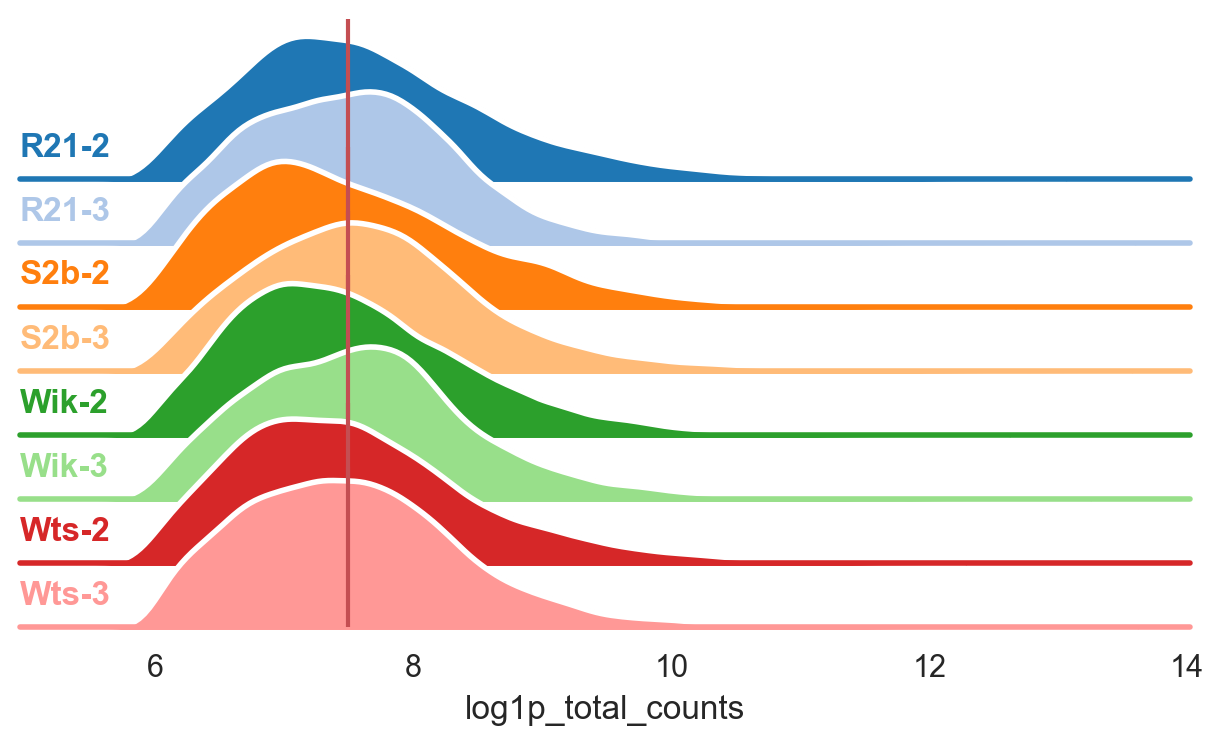

In [14]:
#value = "pct_counts_mt"
#value = "n_genes"
#value = 'pct_counts_in_top_20_genes'
value = "log1p_total_counts"
sns.set(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
g = sns.FacetGrid(df, row="sample", hue="sample", aspect=15, height=0.5, palette="tab20")
g.map(sns.kdeplot, value, clip_on=False, fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, value, clip_on=False, color="w", lw=2)
g.map(plt.axhline, y=0, lw=2, clip_on=False)
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)
g.map(label, value)
g.figure.subplots_adjust(hspace=-.6)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
for ax in g.axes.flat:
    ax.axvline(x=df[value].median(), color='r', linestyle='-')

plt.savefig(fig_path + value)
plt.show()

## Filtering doublets using scVI

In [15]:
scvi.model.SCVI.setup_anndata(adata)
vae = scvi.model.SCVI(adata)
vae.train()

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Epoch 66/66: 100%|█| 66/66 [2:11:43<00:00, 124.12s/it, v_num=1, train_loss_ste

`Trainer.fit` stopped: `max_epochs=66` reached.


Epoch 66/66: 100%|█| 66/66 [2:11:43<00:00, 119.75s/it, v_num=1, train_loss_ste


In [16]:
solo = scvi.external.SOLO.from_scvi_model(vae)
solo.train()

INFO     Creating doublets, preparing SOLO model.                                                                  


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Epoch 289/400:  72%|▋| 289/400 [15:22<05:54,  3.19s/it, v_num=1, train_loss_step=0
Monitored metric validation_loss did not improve in the last 30 records. Best score: 0.356. Signaling Trainer to stop.


In [23]:
df = solo.predict()
df['prediction'] = solo.predict(soft = False)
df

,doublet,singlet,prediction
13_01_32__s1,0.532389,0.467611,doublet
13_01_34__s1,0.820816,0.179184,doublet
13_01_82__s1,0.261586,0.738414,singlet
13_02_26__s1,0.870986,0.129014,doublet
13_02_30__s1,0.814303,0.185697,doublet
...,...,...,...
48_95_46__s8,0.013984,0.986016,singlet
48_95_57__s8,0.267870,0.732131,singlet
48_95_60__s8,0.053286,0.946714,singlet
48_95_65__s8,0.781633,0.218367,doublet


In [24]:
len(df[df.prediction == 'doublet'])

39040

In [25]:
df.to_pickle("doubletpred")

In [26]:
doublets = pd.read_pickle("doubletpred")

In [27]:
adata.obs = adata.obs.merge(right = doublets, left_index=True, right_index=True)

In [28]:
adata.obs

,sample,species,gene_count,tscp_count,mread_count,bc1_wind,bc2_wind,bc3_wind,bc1_well,bc2_well,...,pct_counts_ribo,pct_counts_hb,_scvi_batch,_scvi_labels,doublet_x,singlet_x,prediction_x,doublet_y,singlet_y,prediction_y
13_01_32__s1,R21-2,Law-GRC11,1169,1934,3412,13,1,32,B1,A1,...,0.775595,0.000000,0,0,0.532389,0.467611,doublet,0.532389,0.467611,doublet
13_01_34__s1,R21-2,Law-GRC11,1935,4514,8158,13,1,34,B1,A1,...,0.598139,0.000000,0,0,0.820816,0.179184,doublet,0.820816,0.179184,doublet
13_01_82__s1,R21-2,Law-GRC11,652,1061,1928,13,1,82,B1,A1,...,0.188501,0.000000,0,0,0.261586,0.738414,singlet,0.261586,0.738414,singlet
13_02_26__s1,R21-2,Law-GRC11,4459,11563,20989,13,2,26,B1,A2,...,0.345931,0.000000,0,0,0.870986,0.129014,doublet,0.870986,0.129014,doublet
13_02_30__s1,R21-2,Law-GRC11,5263,14995,26923,13,2,30,B1,A2,...,0.760253,0.013338,0,0,0.814303,0.185697,doublet,0.814303,0.185697,doublet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48_95_46__s8,Wts-3,Law-GRC11,1153,2082,3863,48,95,46,D12,H11,...,0.240154,0.000000,0,0,0.013984,0.986016,singlet,0.013984,0.986016,singlet
48_95_57__s8,Wts-3,Law-GRC11,1006,1672,3099,48,95,57,D12,H11,...,0.478469,0.000000,0,0,0.267870,0.732131,singlet,0.267870,0.732131,singlet
48_95_60__s8,Wts-3,Law-GRC11,622,928,1688,48,95,60,D12,H11,...,0.215517,0.000000,0,0,0.053286,0.946714,singlet,0.053286,0.946714,singlet
48_95_65__s8,Wts-3,Law-GRC11,1470,2730,5136,48,95,65,D12,H11,...,1.684982,0.036630,0,0,0.781633,0.218367,doublet,0.781633,0.218367,doublet


In [ ]:
# Filter the data
#adata = adata[adata.obs.n_genes_by_counts < 5000,:]
#adata = adata[adata.obs.total_counts < 20000,:]
#adata = adata[adata.obs.pct_counts_mt < 15,:]
#adata.shape # Checking number of cells remaining

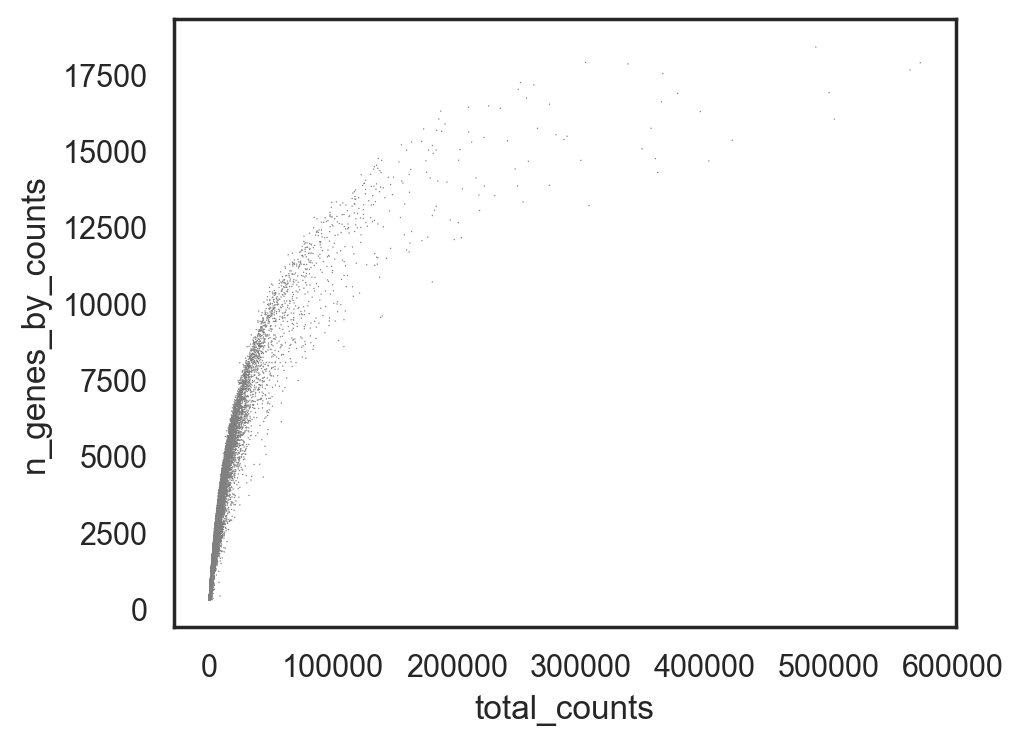

median transcript count per cell: 1789.0
median gene count per cell: 1029.0


In [29]:
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', save='_gene_vs_transcript_counts')
print('median transcript count per cell: ' + str(adata.obs['tscp_count'].median(0)))
print('median gene count per cell: ' + str(adata.obs['gene_count'].median(0)))

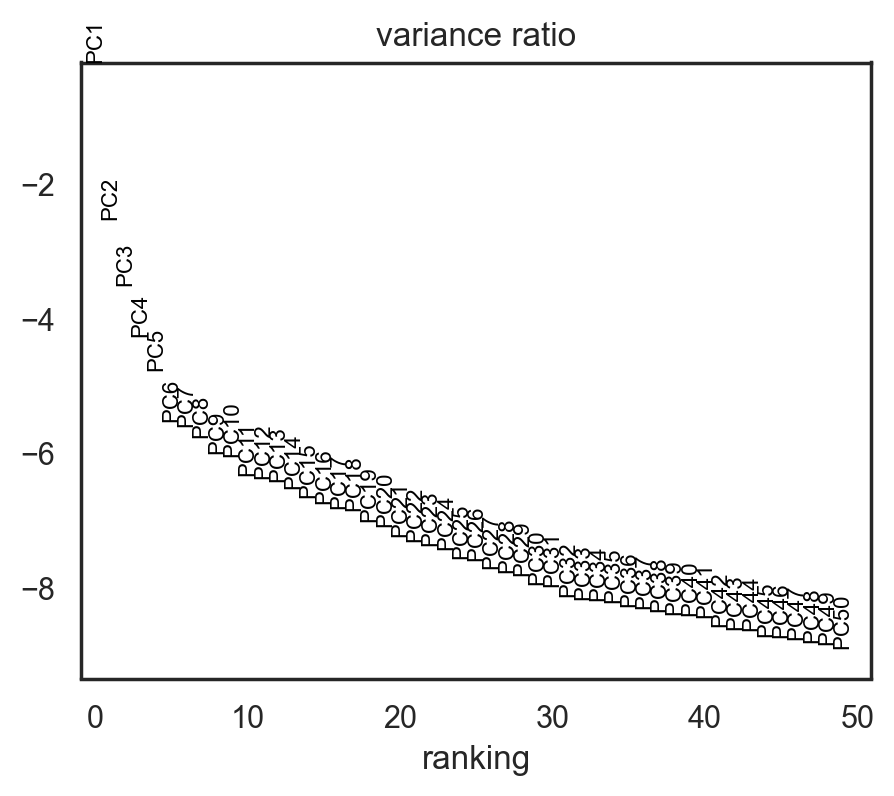

In [30]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50, save='') # scanpy generates the filename automatically

## Saving adata and checking it saved okay

In [31]:
#adata.write(data_path + 'adata_after_diffexp.h5ad')

In [32]:
#adata = sc.read(data_path + 'adata_after_diffexp.h5ad')
adata.obs

,sample,species,gene_count,tscp_count,mread_count,bc1_wind,bc2_wind,bc3_wind,bc1_well,bc2_well,...,pct_counts_ribo,pct_counts_hb,_scvi_batch,_scvi_labels,doublet_x,singlet_x,prediction_x,doublet_y,singlet_y,prediction_y
13_01_32__s1,R21-2,Law-GRC11,1169,1934,3412,13,1,32,B1,A1,...,0.775595,0.000000,0,0,0.532389,0.467611,doublet,0.532389,0.467611,doublet
13_01_34__s1,R21-2,Law-GRC11,1935,4514,8158,13,1,34,B1,A1,...,0.598139,0.000000,0,0,0.820816,0.179184,doublet,0.820816,0.179184,doublet
13_01_82__s1,R21-2,Law-GRC11,652,1061,1928,13,1,82,B1,A1,...,0.188501,0.000000,0,0,0.261586,0.738414,singlet,0.261586,0.738414,singlet
13_02_26__s1,R21-2,Law-GRC11,4459,11563,20989,13,2,26,B1,A2,...,0.345931,0.000000,0,0,0.870986,0.129014,doublet,0.870986,0.129014,doublet
13_02_30__s1,R21-2,Law-GRC11,5263,14995,26923,13,2,30,B1,A2,...,0.760253,0.013338,0,0,0.814303,0.185697,doublet,0.814303,0.185697,doublet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48_95_46__s8,Wts-3,Law-GRC11,1153,2082,3863,48,95,46,D12,H11,...,0.240154,0.000000,0,0,0.013984,0.986016,singlet,0.013984,0.986016,singlet
48_95_57__s8,Wts-3,Law-GRC11,1006,1672,3099,48,95,57,D12,H11,...,0.478469,0.000000,0,0,0.267870,0.732131,singlet,0.267870,0.732131,singlet
48_95_60__s8,Wts-3,Law-GRC11,622,928,1688,48,95,60,D12,H11,...,0.215517,0.000000,0,0,0.053286,0.946714,singlet,0.053286,0.946714,singlet
48_95_65__s8,Wts-3,Law-GRC11,1470,2730,5136,48,95,65,D12,H11,...,1.684982,0.036630,0,0,0.781633,0.218367,doublet,0.781633,0.218367,doublet
